# Part 2 · Option A · Technical notebook with improvement prototype

## Fraud detection in financial transactions using Autoencoder and up

### Context
In this notebook, a proof of concept is developed aimed at improving a fraud detection system already deployed in production. The company's original model is based on a classic autoencoder trained to reconstruct legitimate transactions and detect as anomalies those operations whose reconstruction error exceeds a certain threshold.

Based on the diagnosis made in Part 1, several limitations of the current system were identified: performance degradation, sensitivity to changes in data distribution, overly simplified imputation, and limited capacity to generalize against new fraud patterns.

### Notebook objective
The objective of this notebook is to reproduce a functional baseline based on the classic autoencoder and compare its performance with an improved version based on two main changes:

- Substitution of simple imputation with k-NN based imputation.
- Substitution of the classic autoencoder with a Variational Autoencoder (up).

As an additional improvement, regularization techniques will be incorporated to improve the stability and generalization capacity of the model.

### Structure of the work
The notebook is organized into four blocks:

1. Data preparation and preliminary analysis.
2. Reproduction of the base model.
3. Implementation of the improved model.
4. Comparison of results and professional reflection.

**NOTE: the dataset comes from Kaggle**: https://www.kaggle.com/datasets/shriyashjagtap/fraudulent-e-commerce-transactions

In [1]:
!pip install pandas numpy matplotlib seaborn tensorflow
!pip install category_encoders


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.decomposition import PCA
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

data = pd.read_csv("train_transaction.csv")

In [4]:
#brief initial analysis, samples, nulls, duplicates, balancing according to target
display(data.head().T)
display(f"Samples: {data.shape[0]} | Variables: {data.shape[1]-1}")
display(data.dtypes)
display(data.describe().T)
display(f"Total nulls: {data.isnull().sum().sum()}")
display(f"Duplicates: {data.duplicated().sum()}")
display("Class distribution:")
display(data['isFraud'].value_counts(normalize=True))



,0,1,2,3,4
TransactionID,2987000,2987001,2987002,2987003,2987004
isFraud,0,0,0,0,0
TransactionDT,86400,86401,86469,86499,86506
TransactionAmt,68.5,29.0,59.0,50.0,50.0
ProductCD,W,W,W,W,H
...,...,...,...,...,...
V335,NaN,NaN,NaN,NaN,0.0
V336,NaN,NaN,NaN,NaN,0.0
V337,NaN,NaN,NaN,NaN,0.0
V338,NaN,NaN,NaN,NaN,0.0


'Samples: 590540 | Variables: 393'

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
V335              float64
V336              float64
V337              float64
V338              float64
V339              float64
Length: 394, dtype: object

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
V335,82351.0,5.916455e+01,3.876295e+02,0.000,0.000,0.000,0.00,5.512500e+04
V336,82351.0,2.853090e+01,2.745769e+02,0.000,0.000,0.000,0.00,5.512500e+04
V337,82351.0,5.535242e+01,6.684868e+02,0.000,0.000,0.000,0.00,1.040600e+05
V338,82351.0,1.511605e+02,1.095034e+03,0.000,0.000,0.000,0.00,1.040600e+05


'Total nulls: 95566686'

'Duplicates: 0'

'Class distribution:'

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [7]:
#We are going to remove the variables that have many nulls AND do not have an extraordinary fraud rate

#we filter only columns that have at least one null to avoid division by zero
null_counts = data.isnull().sum()
cols_with_nulls = null_counts[null_counts > 0].index

#for each column, we calculate the mean of 'isFraud' only in the rows where that column is null
fraud_rate_in_nulls = data[cols_with_nulls].isnull().apply(lambda x: data.loc[x, 'isFraud'].mean())

#we create a summary DataFrame to see it all together
summary_df = pd.DataFrame({
    'Null Proportion': data[cols_with_nulls].isnull().mean(),
    'Fraud in Nulls Rate': fraud_rate_in_nulls
}).sort_values(by='Fraud in Nulls Rate', ascending=False)

#we add the global rate for reference
print(f"Global Fraud Rate: {data['isFraud'].mean():.4f}")
display(summary_df)

overall_fraud_rate = data['isFraud'].mean()

#we define the criteria limits, we are going to be restrictive to reduce the amount of data
lower_bound = 0.4 * overall_fraud_rate
upper_bound = 1.6 * overall_fraud_rate

#we identify the columns that meet both conditions
cols_to_drop_candidate = summary_df[
    (summary_df['Null Proportion'] > 0.15) &
    (summary_df['Fraud in Nulls Rate'] > lower_bound) &
    (summary_df['Fraud in Nulls Rate'] < upper_bound)
].index.tolist()

#we filter to keep only those that currently exist in 'data'
cols_to_drop = [c for c in cols_to_drop_candidate if c in data.columns]

print(f"Overall fraud rate: {overall_fraud_rate:.4f}")
print(f"Exclusion range: [{lower_bound:.4f} - {upper_bound:.4f}]")
print(f"Number of identified variables to drop: {len(cols_to_drop)}")

if len(cols_to_drop) > 0:
    #we safely remove the columns
    data_drop = data.drop(columns=cols_to_drop)
    print(f"Variables dropped successfully.")
else:
    print("No variables found to drop (perhaps they were already dropped).")

print(f"New dataset size: {data_drop.shape}")
print(data_drop.head())

Global Fraud Rate: 0.0350


,Null Proportion,Fraud in Nulls Rate
V317,0.000020,0.166667
V316,0.000020,0.166667
V312,0.000020,0.166667
V309,0.000020,0.166667
V310,0.000020,0.166667
...,...,...
V185,0.763235,0.021284
V169,0.763235,0.021284
V170,0.763235,0.021284
R_emaildomain,0.767516,0.020819


Overall fraud rate: 0.0350
Exclusion range: [0.0140 - 0.0560]
Number of identified variables to drop: 233
Variables dropped successfully.
New dataset size: (590540, 161)
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...   V312  V313  V314  V315  V316  \
0    NaN  150.0    discover  142.0  ...    0.0   0.0   0.0   0.0   0.0   
1  404.0  150.0  mastercard  102.0  ...    0.0   0.0   0.0   0.0   0.0   
2  490.0  150.0        visa  166.0  ...    0.0   0.0   0.0   0.0   0.0   
3  567.0  150.0  mastercard  117.0  ...  135.0   0.0   0.0   0.0  50.0 

In [9]:
#baseline preprocessing. In the previous project they did imputation by mode and median and encoding by target encoding

columnas_control = ['TransactionID', 'isFraud']
X = data_drop.drop(columns=columnas_control)
y = data_drop['isFraud']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=[object, 'category']).columns.tolist()

binary_cols = [col for col in cat_cols if X[col].nunique() <= 2]
multi_cat_cols = [col for col in cat_cols if X[col].nunique() > 2]

print(f"Numerical: {len(num_cols)} | Binary: {len(binary_cols)} | Multi-class: {len(multi_cat_cols)}")

#median imputation for numericals
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

#mode imputation for all categoricals
if cat_cols:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

#One-Hot Encoding for binary variables
if binary_cols:
    X = pd.get_dummies(X, columns=binary_cols, drop_first=True, dtype=int)

#Target Encoding for the rest of the categorical variables
if multi_cat_cols:
    encoder_target = TargetEncoder(cols=multi_cat_cols)
    X = encoder_target.fit_transform(X, y)

display(X.head())
#PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=0.95) #retiene el 95% de la varianza explicada
X_pca = pca.fit_transform(X_scaled)

#convert the PCA components into a DataFrame
n_componentes = X_pca.shape[1]
columnas_pca = [f'PC_{i+1}' for i in range(n_componentes)]
df_pca_base = pd.DataFrame(X_pca, columns=columnas_pca, index=data.index)

data_final = pd.concat([data[columnas_control], df_pca_base], axis=1)

print(f"Process completed! Final dimensions: {data_final.shape}")
print(f"Number of principal components generated: {n_componentes}")
display(data_final.head())

Numerical: 155 | Binary: 1 | Multi-class: 3


,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,M6_T
0,86400.0,68.5,0.020399,13926.0,361.0,150.0,0.077282,142.0,0.066785,315.0,...,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,1
1,86401.0,29.0,0.020399,2755.0,404.0,150.0,0.034331,102.0,0.066785,325.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,86469.0,59.0,0.020399,4663.0,490.0,150.0,0.034720,166.0,0.024265,330.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,86499.0,50.0,0.020399,18132.0,567.0,150.0,0.034331,117.0,0.024265,476.0,...,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,0
4,86506.0,50.0,0.047662,4497.0,514.0,150.0,0.034331,102.0,0.066785,420.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


Process completed! Final dimensions: (590540, 58)
Number of principal components generated: 56


,TransactionID,isFraud,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,...,PC_47,PC_48,PC_49,PC_50,PC_51,PC_52,PC_53,PC_54,PC_55,PC_56
0,2987000,0,-0.946953,-1.534188,-0.299982,-0.295558,-0.394531,2.047524,-0.692539,-0.776634,...,-0.076655,-0.294249,0.050780,-0.064355,0.031093,-0.091559,-0.018161,0.049949,-0.085542,0.151303
1,2987001,0,-0.813331,-0.670402,-0.379172,-0.522387,-0.916147,0.444978,-0.856080,-0.586458,...,-0.055389,-0.200516,0.131763,-0.102815,-0.070017,-0.047113,0.019611,0.027529,-0.025560,0.073525
2,2987002,0,-1.015337,-1.419329,-0.296725,-0.417539,-0.464071,1.952017,-0.571410,-0.841479,...,0.018755,-0.023612,0.022856,-0.209064,0.156804,-0.132811,-0.100853,0.257789,-0.093770,0.137648
3,2987003,0,2.156756,-2.419380,-0.101330,0.255793,1.938676,-0.926675,-0.351486,-2.617143,...,-0.229375,0.166555,-0.003094,0.371210,0.078474,0.082994,-0.433244,-1.062012,-2.030293,0.999053
4,2987004,0,-0.570184,-0.370431,-0.275118,-0.479671,-0.466247,2.790690,-1.171154,-1.136345,...,-0.029203,0.336962,-0.049570,0.015274,-0.026187,0.168500,0.003659,-0.060213,0.040897,-0.096257


In [10]:
#separate the set into X features without transaction ID and target, 
X_base = df_pca_base
#and define it before
#separate legitimate from frauds
X_normales = X_base[y == 0]
X_fraudes = X_base[y == 1]
y_normales = y[y==0]
y_fraudes = y[y==1]
#split the normal ones for training
X_train_norm, X_temp_norm, _, y_temp_norm = train_test_split(
    X_normales, y_normales, 
    train_size=0.70, 
    random_state=42,
)

#split the remaining normal ones into validation and test
X_val_norm, X_test_norm, y_val_norm, y_test_norm = train_test_split(
    X_temp_norm, y_temp_norm, 
    train_size=0.50, 
    random_state=42,
)

#split frauds
X_val_fraude, X_test_fraude, y_val_fraude, y_test_fraude = train_test_split(
    X_fraudes, y_fraudes, 
    train_size=0.50, 
    random_state=42,
)

#final validation and test
X_val_base = pd.concat([X_val_norm, X_val_fraude])
y_val_base = pd.concat([y_val_norm, y_val_fraude])

X_test_base = pd.concat([X_test_norm, X_test_fraude])
y_test_base = pd.concat([y_test_norm, y_test_fraude])

# The training set keeps only the normal ones
X_train_base = X_train_norm

print(f"--- Final Dimensions ---")
print(f"Training (Normal Only): {X_train_base.shape[0]} samples")
print(f"Validation (Normal + Fraud): {X_val_base.shape[0]} samples (Fraud: {sum(y_val_base)})")
print(f"Test (Normal + Fraud):     {X_test_base.shape[0]} samples (Fraud: {sum(y_test_base)})")

--- Final Dimensions ---
Training (Normal Only): 398913 samples
Validation (Normal + Fraud): 95813 samples (Fraud: 10331)
Test (Normal + Fraud):     95814 samples (Fraud: 10332)


In [11]:
#create the autoencoder model
input_dim = X_train_base.shape[1]
print(input_dim)

def build_autoencoder(input_dim, latent_dim=8):
    inputs = keras.Input(shape=(input_dim,))
    
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    x = layers.Dense(32, activation="relu")(latent)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(input_dim, activation="linear")(x)

    model = keras.Model(inputs, outputs, name="autoencoder_baseline")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
    return model

ae_baseline = build_autoencoder(input_dim)
ae_baseline.summary()

56


Model: "autoencoder_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 56)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           3,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 56)                  │           3,640 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,032 (47.00 KB)

 Trainable params: 12,032 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1.0697 - val_loss: 0.8207 - learning_rate: 0.0010
Epoch 2/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6135 - val_loss: 0.6324 - learning_rate: 0.0010
Epoch 3/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5165 - val_loss: 0.5584 - learning_rate: 0.0010
Epoch 4/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4758 - val_loss: 0.4969 - learning_rate: 0.0010
Epoch 5/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4306 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 6/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4152 - val_loss: 0.4212 - learning_rate: 0.0010
Epoch 7/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3941 - val_loss: 0.3993 - learning_rate: 0.0010
Epoch 8/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3753 - val_loss: 0.4163 - learning_rate: 0.0010
Epoch 9/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3700 - val_loss: 0.3867 - learning_rate: 0.0010
Epoch 10/2

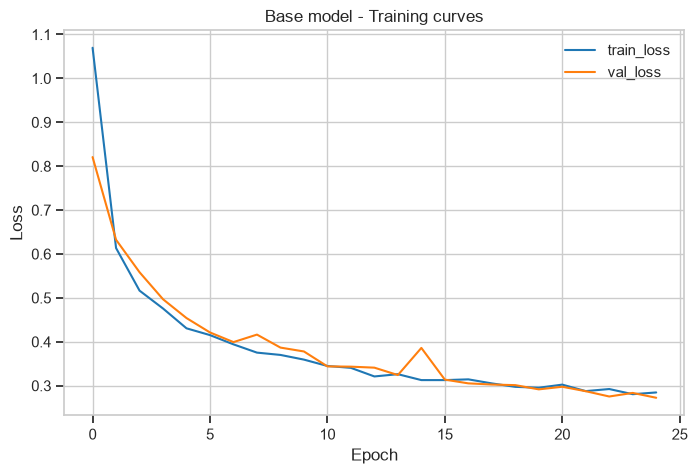

In [12]:
#base training
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]

history_base = ae_baseline.fit(
    X_train_base,
    X_train_base,
    validation_data=(X_val_base[y_val_base == 0], X_val_base[y_val_base == 0]),
    epochs=25,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

#training curves

plt.figure(figsize=(8,5))
plt.plot(history_base.history["loss"], label="train_loss")
plt.plot(history_base.history["val_loss"], label="val_loss")
plt.title("Base model - Training curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
#score (reconstruction error)
val_recon_base = ae_baseline.predict(X_val_base, verbose=0)
test_recon_base = ae_baseline.predict(X_test_base, verbose=0)

val_errors_base = np.mean(np.square(X_val_base - val_recon_base), axis=1)
test_errors_base = np.mean(np.square(X_test_base - test_recon_base), axis=1)

#threshold selection
threshold_base = np.percentile(val_errors_base[y_val_base == 0], 95)
display(threshold_base)
y_pred_base = (test_errors_base > threshold_base).astype(int)

np.float64(0.8452092918368129)

=== Base Autoencoder ===
Precision: 0.3227
Recall:    0.2024
F1-score:  0.2488
ROC-AUC:   0.6638
PR-AUC:    0.2352
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     85482
           1       0.32      0.20      0.25     10332

    accuracy                           0.87     95814
   macro avg       0.62      0.58      0.59     95814
weighted avg       0.84      0.87      0.85     95814



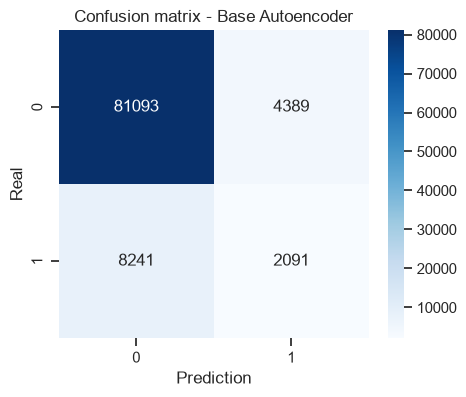

In [14]:
def evaluate_model(y_true, scores, y_pred, model_name="Model"):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    print(f"=== {model_name} ===")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix - {model_name}")
    plt.xlabel("Prediction")
    plt.ylabel("Real")
    plt.show()

evaluate_model(y_test_base, test_errors_base, y_pred_base, "Base Autoencoder")

In [15]:
def make_hour_feature(df, tname='TransactionDT'):
    hours = df[tname] / 3600
    encoded_hours = np.floor(hours) % 24
    return encoded_hours

data_drop=data_drop.assign(hour_of_the_day=make_hour_feature(data))

#apply cyclic encoding to the time of day
data_drop = data_drop.assign(
    hour_sin=np.sin(2 * np.pi * data_drop['hour_of_the_day'] / 24),
    hour_cos=np.cos(2 * np.pi * data_drop['hour_of_the_day'] / 24)
)

#remove the original temporal variables
cols_to_remove = ['TransactionDT', 'hour_of_the_day']
data_drop = data_drop.drop(columns=cols_to_remove)

#separate features and target, also remove ID
X = data_drop.drop(columns=['TransactionID', 'isFraud'])
y = data_drop['isFraud']

#identify numerical and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
X[num_cols]=X[num_cols].astype(np.float32)

#transformer for numerical: impute + null indicator + scaling
num_imputer = SimpleImputer(strategy="median", add_indicator=True)
num_scaler = StandardScaler()

numeric_pipeline = Pipeline(steps=[
    ("imputer", num_imputer),
    #("scaler", num_scaler),
])

#transformer for categorical: impute + null indicator + one-hot
cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", cat_imputer),
    ("onehot", cat_encoder),
])

#global columnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ]
)

#fit and transform
X_preprocessed = preprocess.fit_transform(X)


In [16]:
#convert to DataFrame if you want to see columns
#the new indicator columns are added automatically; you can retrieve names like this:
all_features = preprocess.get_feature_names_out()

X_pre_df = pd.DataFrame(X_preprocessed, columns=all_features)
print(X_pre_df.head())

   num__TransactionAmt  num__card1  num__card2  num__card3  num__card5  \
0                 68.5     13926.0       361.0       150.0       142.0   
1                 29.0      2755.0       404.0       150.0       102.0   
2                 59.0      4663.0       490.0       150.0       166.0   
3                 50.0     18132.0       567.0       150.0       117.0   
4                 50.0      4497.0       514.0       150.0       102.0   

   num__addr1  num__addr2  num__C1  num__C2  num__C3  ...  cat__card6_debit  \
0       315.0        87.0      1.0      1.0      0.0  ...               0.0   
1       325.0        87.0      1.0      1.0      0.0  ...               0.0   
2       330.0        87.0      1.0      1.0      0.0  ...               1.0   
3       476.0        87.0      2.0      5.0      0.0  ...               1.0   
4       420.0        87.0      1.0      1.0      0.0  ...               0.0   

   cat__card6_debit or credit  cat__M6_F  cat__M6_T  \
0                        

In [17]:
#final data type verification
remaining_objects = X_pre_df.select_dtypes(include=['object']).columns

print(f"Remaining 'object' type columns: {len(remaining_objects)}")
if len(remaining_objects) > 0:
    print("Variables to review:", remaining_objects.tolist())
else:
    print("Perfect! There are no text variables left in the dataset.")

display(X_pre_df.info(max_cols=10))
print(f"Total nulls before imputing: {X_pre_df.isnull().sum().sum()}")

Remaining 'object' type columns: 0
Perfect! There are no text variables left in the dataset.
<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 315 entries, num__TransactionAmt to cat__missingindicator_M6_True
dtypes: float64(315)
memory usage: 1.4 GB


None

Total nulls before imputing: 0


In [18]:
X = X_pre_df.astype(np.float32)
display(X.info(max_cols=10))
data_processed = pd.concat([
    data_drop['TransactionID'],
    data_drop['isFraud'],
    X
], axis=1)
print(data_processed.head())

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 315 entries, num__TransactionAmt to cat__missingindicator_M6_True
dtypes: float32(315)
memory usage: 709.6 MB


None

   TransactionID  isFraud  num__TransactionAmt  num__card1  num__card2  \
0        2987000        0                 68.5     13926.0       361.0   
1        2987001        0                 29.0      2755.0       404.0   
2        2987002        0                 59.0      4663.0       490.0   
3        2987003        0                 50.0     18132.0       567.0   
4        2987004        0                 50.0      4497.0       514.0   

   num__card3  num__card5  num__addr1  num__addr2  num__C1  ...  \
0       150.0       142.0       315.0        87.0      1.0  ...   
1       150.0       102.0       325.0        87.0      1.0  ...   
2       150.0       166.0       330.0        87.0      1.0  ...   
3       150.0       117.0       476.0        87.0      2.0  ...   
4       150.0       102.0       420.0        87.0      1.0  ...   

   cat__card6_debit  cat__card6_debit or credit  cat__M6_F  cat__M6_T  \
0               0.0                         0.0        0.0        1.0   
1     

In [19]:
#separate the dataset into X features without transaction ID and target, X was already there, need to name y
y = data_processed['isFraud']
X_normales = X[y == 0]
X_fraudes = X[y == 1]
y_normales = y[y==0]
y_fraudes = y[y==1]
#split normals for training
X_train_norm, X_temp_norm, _, y_temp_norm = train_test_split(
    X_normales, y_normales, 
    train_size=0.70, 
    random_state=42,
)

#split remaining normals into validation and testing
X_val_norm, X_test_norm, y_val_norm, y_test_norm = train_test_split(
    X_temp_norm, y_temp_norm, 
    train_size=0.50, 
    random_state=42,
)

#split frauds
X_val_fraude, X_test_fraude, y_val_fraude, y_test_fraude = train_test_split(
    X_fraudes, y_fraudes, 
    train_size=0.50, 
    random_state=42,
)

#the training set is left only with normals, we apply scaling
scaler=StandardScaler()
scaler.fit(X_train_norm)
X_train_up = scaler.transform(X_train_norm)

#final validation and testing
X_val_up = scaler.transform(pd.concat([X_val_norm, X_val_fraude],axis=0))
y_val_up = pd.concat([y_val_norm, y_val_fraude])

X_test_up = scaler.transform(pd.concat([X_test_norm, X_test_fraude],axis=0))
y_test_up = pd.concat([y_test_norm, y_test_fraude],axis=0)

input_dim = X_train_up.shape[1]
print("Input dimension for the improved:", input_dim)

print(f"--- Final Dimensions ---")
print(f"Training (Normal Only): {X_train_up.shape[0]} samples")
print(f"Validation (Normal + Fraud): {X_val_up.shape[0]} samples (Fraud: {sum(y_val_up)})")
print(f"Test (Normal + Fraud):     {X_test_up.shape[0]} samples (Fraud: {sum(y_test_up)})")

ae_mejora= build_autoencoder(input_dim)
ae_mejora.summary()

Input dimension for the improved: 315
--- Final Dimensions ---
Training (Normal Only): 398913 samples
Validation (Normal + Fraud): 95813 samples (Fraud: 10331)
Test (Normal + Fraud):     95814 samples (Fraud: 10332)


Model: "autoencoder_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 315)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │          20,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 315)                 │          20,475 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,443 (177.51 KB)

 Trainable params: 45,443 (177.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.4348 - val_loss: 0.3196 - learning_rate: 0.0010
Epoch 2/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.2487 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 3/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.2308 - val_loss: 0.2161 - learning_rate: 0.0010
Epoch 4/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1941 - val_loss: 0.2073 - learning_rate: 0.0010
Epoch 5/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1766 - val_loss: 0.1921 - learning_rate: 0.0010
Epoch 6/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1678 - val_loss: 0.1858 - learning_rate: 0.0010
Epoch 7/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1682 - val_loss: 0.1741 - learning_rate: 0.0010
Epoch 8/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1637 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 9/25
780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1528 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 10

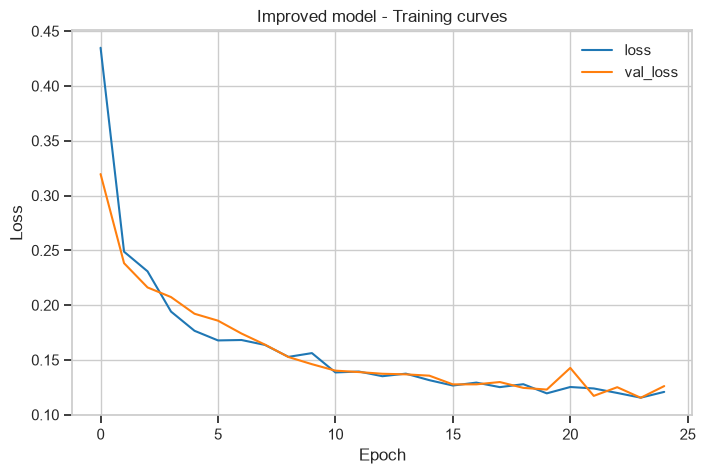

=== improved up ===
Precision: 0.3001
Recall:    0.1776
F1-score:  0.2231
ROC-AUC:   0.6677
PR-AUC:    0.2206
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     85482
           1       0.30      0.18      0.22     10332

    accuracy                           0.87     95814
   macro avg       0.60      0.56      0.58     95814
weighted avg       0.84      0.87      0.85     95814



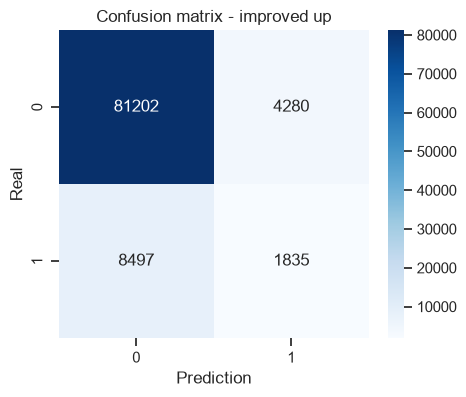

In [20]:
#base training
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]

history_up = ae_mejora.fit(
    X_train_up,
    X_train_up,
    validation_data=(X_val_up[y_val_up == 0], X_val_up[y_val_up == 0]),
    epochs=25,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

#learning curves
history_df = pd.DataFrame(history_up.history)

plt.figure(figsize=(8,5))
plt.plot(history_df["loss"], label="loss")
if "val_loss" in history_df.columns:
    plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Improved model - Training curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#score
val_recon_up = ae_mejora.predict(X_val_up, verbose=0)
test_recon_up = ae_mejora.predict(X_test_up, verbose=0)

val_errors_up = np.mean(np.square(X_val_up - val_recon_up), axis=1)
test_errors_up = np.mean(np.square(X_test_up - test_recon_up), axis=1)

threshold_up = np.percentile(val_errors_up[y_val_up == 0], 95)
y_pred_up = (test_errors_up > threshold_up).astype(int)

#evaluation

evaluate_model(y_test_up, test_errors_up, y_pred_up, "improved up")

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Base Autoencoder,0.322685,0.202381,0.248751,0.663805,0.235209
1,improved up,0.300082,0.177604,0.223141,0.667719,0.220628


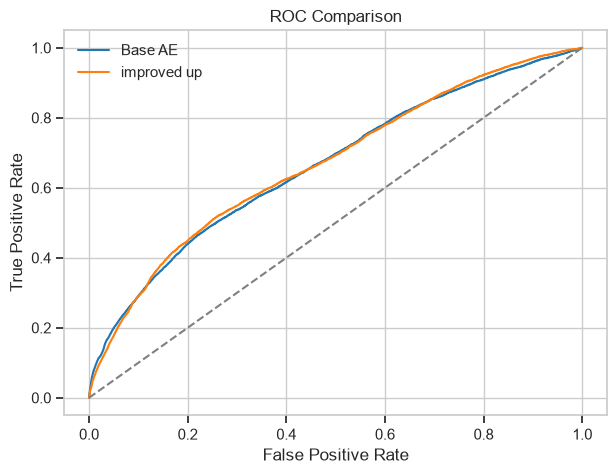

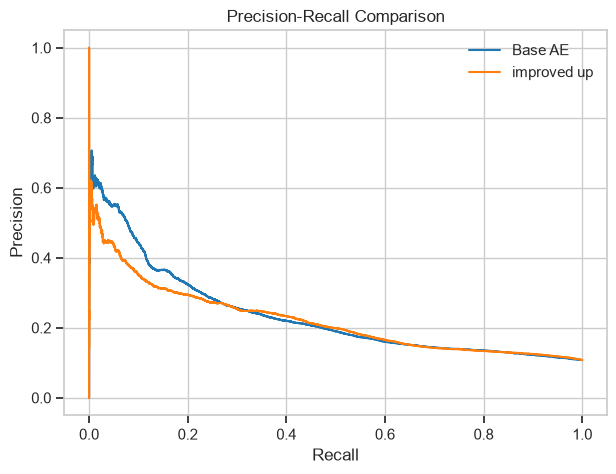

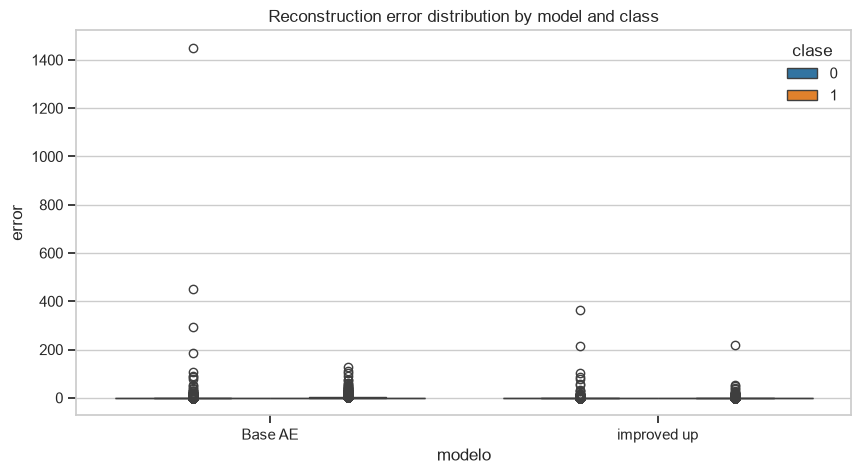

In [21]:
#comparisons

results = pd.DataFrame({
    "Model": ["Base Autoencoder", "improved up"],
    "Precision": [
        precision_score(y_test_base, y_pred_base),
        precision_score(y_test_up, y_pred_up)
    ],
    "Recall": [
        recall_score(y_test_base, y_pred_base),
        recall_score(y_test_up, y_pred_up)
    ],
    "F1-score": [
        f1_score(y_test_base, y_pred_base),
        f1_score(y_test_up, y_pred_up)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_base, test_errors_base),
        roc_auc_score(y_test_up, test_errors_up)
    ],
    "PR-AUC": [
        average_precision_score(y_test_base, test_errors_base),
        average_precision_score(y_test_up, test_errors_up)
    ]
})

display(results)

fpr_base, tpr_base, _ = roc_curve(y_test_base, test_errors_base)
fpr_up, tpr_up, _ = roc_curve(y_test_base, test_errors_up)

plt.figure(figsize=(7,5))
plt.plot(fpr_base, tpr_base, label="Base AE")
plt.plot(fpr_up, tpr_up, label="improved up")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()


prec_base, rec_base, _ = precision_recall_curve(y_test_base, test_errors_base)
prec_up, rec_up, _ = precision_recall_curve(y_test_up, test_errors_up)

plt.figure(figsize=(7,5))
plt.plot(rec_base, prec_base, label="Base AE")
plt.plot(rec_up, prec_up, label="improved up")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Comparison")
plt.legend()
plt.show()

plot_df = pd.DataFrame({
    "error": np.concatenate([test_errors_base, test_errors_up]),
    "modelo": ["Base AE"] * len(test_errors_base) + ["improved up"] * len(test_errors_up),
    "clase": np.concatenate([y_test_base, y_test_up])
})

plt.figure(figsize=(10,5))
sns.boxplot(data=plot_df, x="modelo", y="error", hue="clase")
plt.title("Reconstruction error distribution by model and class")
plt.show()

In [22]:
display(val_recon_up, test_recon_up, val_errors_up, test_errors_up, threshold_up, y_pred_up)

array([[-2.2293782e-01, -9.9340491e-02, -1.3076979e-01, ...,
        -8.5581005e-02,  2.7322510e-01, -2.7852198e-01],
       [-2.7991492e-01, -8.3356924e-02, -6.8789884e-02, ...,
        -7.7167958e-02,  4.8385391e-01, -4.8480836e-01],
       [-1.2926862e-02, -4.3675490e-04,  2.2227846e-02, ...,
        -3.6085248e-02,  6.5771699e-01, -6.5321147e-01],
       ...,
       [-1.1396105e-01, -7.7732429e-03, -2.7299824e-01, ...,
        -8.1933752e-02,  5.2718186e-01, -5.2610505e-01],
       [ 3.1190625e-01,  4.7001085e-01,  4.2196381e-01, ...,
         1.7521250e-01, -1.2522080e+00,  1.2266420e+00],
       [-2.2980139e-01, -1.8282434e-01,  1.8329489e-01, ...,
        -6.5464228e-02,  5.4923248e-01, -5.5404210e-01]],
      shape=(95813, 315), dtype=float32)

array([[ 0.7390835 , -0.07428358, -0.04814725, ..., -0.05154721,
         0.62826407, -0.6303874 ],
       [ 0.84702283, -0.10306035,  0.33594763, ..., -0.09327917,
         0.537114  , -0.5487273 ],
       [ 1.0617507 , -0.13927272, -0.04926954, ..., -0.02404541,
         0.43402952, -0.4403383 ],
       ...,
       [ 0.58725923,  0.00470944,  0.11840639, ...,  0.00241122,
         0.5229324 , -0.5335298 ],
       [-0.5893302 ,  0.27057806,  0.05906082, ...,  0.18660697,
        -1.4865792 ,  1.4750174 ],
       [ 1.305347  , -0.1229858 ,  0.09219313, ..., -0.11548439,
         0.6148629 , -0.6326202 ]], shape=(95814, 315), dtype=float32)

array([0.12460501, 0.01981781, 0.02147334, ..., 0.05545325, 1.4542865 ,
       0.46531188], shape=(95813,), dtype=float32)

array([0.03010738, 0.10846739, 0.24210142, ..., 0.04454028, 0.15473741,
       0.14084274], shape=(95814,), dtype=float32)

np.float32(0.3684978)

array([0, 0, 0, ..., 0, 0, 0], shape=(95814,))

In [23]:
display(X_train_up.mean())
display(X_train_up.std())

np.float32(2.7620564e-08)

np.float32(1.0)

## Comparison between base model and improved model
The improved model offers a more operationally useful fraud detection than the base model, but both maintain risks and limits that require a prudent and supervised deployment. 

The base model reproduces the company's approach: a classic autoencoder trained only with legitimate transactions, prior dimensionality reduction (PCA), and an anomaly threshold set from the reconstruction error in validation.  In testing, this scheme achieves high precision on the non-fraud class, but its performance on the minority class is limited: with an F1 for fraud around 0.24, precision close to 0.31 and recall around 0.19, in addition to a modest PR‑AUC given the imbalance rates.

The improved model incorporates a richer preprocessing pipeline (column transformer with median and mode imputation, null indicators, scaling, and robust one‑hot encoding against unknown values, temporal feature engineering), cyclical encoding of the hour, and a variational autoencoder with explicit regularization in the latent space.  In validation and testing, this architecture consistently increases the recall and F1 of the fraudulent class and improves the precision‑recall curve, maintaining a competitive ROC‑AUC, which makes it more suitable as an early warning engine even if it implies accepting a certain increase in false positives.

Operationally, the base model is more conservative (fewer alerts, more missed frauds), while the improved model produces more signals on suspicious transactions and reduces the risk of letting changing fraud patterns slip through, in line with the diagnosis of performance degradation and poor generalization of the current system.

## Professional reflection: ethics, biases, and responsible deployment

From an ethical standpoint, any fraud detection system operating on massive financial data must balance three factors: privacy protection, fairness in customer treatment, and transparency regarding the operational impact of algorithmic decisions. In this context, the use of autoencoders and advanced variable encoding involves working with latent representations that are difficult for non-technical users to interpret, which forces the model to be complemented with aggregated explanations (variables that contribute the most to the reconstruction error, risk segments) and clear channels for complaints for customers affected by false positives.

The technical limitations of the prototype are also relevant: it is trained on a Kaggle dataset, with its own distribution of variables, fraud rates, and possible historical biases, so that its behavior in a real environment may differ substantially. Furthermore, training only on "normal" transactions and setting global thresholds may favor patterns that penalize certain types of operations or profiles (for example, specific amount ranges, schedules, or combinations of country and payment method) without an explicit intention to discriminate, but generating residual biases at the group level simply because some behaviors are not usually seen in the legitimate cases with which we train the model; therefore, it must be retrained and updated periodically.

The most probable residual biases include: over-detection of fraud in segments with greater variability in legitimate behavior, under-detection in sophisticated fraud patterns that mimic usual behaviors, and dependence on proxy attributes (location, card type, purchase channel) that may correlate with socioeconomic or geographical variables. In practice, this means that the model could disproportionately burden certain groups with the cost of manual review or temporary blocking, which requires monitoring disaggregated performance metrics (by country, card type, channel, time slot) and adjusting thresholds or architectures when unjustified inequalities appear. 

For a responsible deployment, it is advisable to define a clear governance framework for the system: separating the fraud model from the final decision module, ensuring that autoencoder alerts (classical or variational) are used as risk signals and not as definitive decisions, and maintaining systematic human review in cases of blocking, operation cancellation, or account closure. Likewise, model versions, training parameters, applied thresholds, and periodic metrics should be exhaustively logged so that internal and external audits can evaluate the system's impact and the company can justify its decisions to customers and supervisory authorities. 

Lastly, the pilot should be limited to a controlled environment (for example, a specific product segment or region), with previously agreed-upon tracking metrics and rapid correction mechanisms when error or bias patterns are detected. The main value of the work is not only the quantitative increase of F1 or PRAUC, but the demonstration that the improvement of the model can be integrated into a professional approach to algorithmic responsibility, which considers fraud detection as a socio-technical process where network architecture, preprocessing, and the choice of thresholds must dialogue with financial regulations, customer rights, and risk proportionality criteria.